Este notebook documenta la implementación general de Reinforcement Learning desarrollada en `src/deep_rl_agent/`: un agente **PPO** (Proximal Policy Optimization, Schulman et al., 2017) equipado con un encoder convolucional profundo **IMPALA-CNN** (Espeholt et al., 2018) para entornos Arcade Learning Environment (ALE / Atari).

La arquitectura está desacoplada y diseñada de forma modular para soportar múltiples entornos de Atari (incluyendo `ALE/Breakout-v5` y `ALE/Frogger-v5`). El notebook analiza la arquitectura de red compartida actor-critic, el pipeline de preprocesamiento de observaciones (FrameStack, AtariPreprocessing, FireReset), las curvas de optimización y convergencia en TensorBoard, y la evaluación determinista del mejor checkpoint entrenado junto con la grabación del agente en acción.

Las referencias completas están al final del documento.

In [1]:
# | include: false

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from deep_rl_agent.agent import ImpalaPPOAgent
from deep_rl_agent.config import TrainingConfig
from deep_rl_agent.visualize import make_eval_env

t_config = TrainingConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | run_name base: {t_config.run_name}")

Device: cuda | run_name base: Breakout-v5__envs_8__steps_128__lr_0.00025__seed_1000


# Arquitectura

El agente comparte un único encoder entre la política (actor) y la función de valor (critic):

- **`ImpalaCNN`**: tres bloques `ConvSequence` (64 → 128 → 128 canales), cada uno con una conv 3×3, max-pool 3×3/stride 2 y dos `ResidualBlock` (pre-activación, `relu → conv → relu → conv` + skip). Este encoder es más profundo que la CNN clásica de Nature (Mnih et al., 2015) gracias a las conexiones residuales, lo que ayuda a que el gradiente no se degrade con más capas.
- **Cabezas actor/critic**: cada una es un `Linear → ReLU` de 512 unidades sobre el embedding aplanado, seguido de la salida final (logits de acción para el actor, escalar de valor para el critic).
- La observación se normaliza a `[0, 1]` (`x / 255.0`) antes de entrar al encoder.

In [2]:
# | echo: false
# | eval: true

eval_env = make_eval_env(render_mode="rgb_array")

agent = ImpalaPPOAgent(
    observation_space=eval_env.observation_space,
    action_space=eval_env.action_space,
    device=device,
)

n_params = sum(p.numel() for p in agent.network.parameters())
n_encoder = sum(p.numel() for p in agent.network.encoder.parameters())
print(f"Observation space: {eval_env.observation_space.shape}")
print(f"Action space: {eval_env.action_space.n} ({eval_env.unwrapped.get_action_meanings()})")
print(f"Parámetros totales: {n_params:,} (encoder: {n_encoder:,})")

Observation space: (4, 84, 84)
Action space: 4 (['NOOP', 'FIRE', 'RIGHT', 'LEFT'])
Parámetros totales: 17,415,493 (encoder: 1,552,192)


## Pipeline de observación

Cada entorno pasa por la misma cadena de wrappers en entrenamiento (`train.py`) y en evaluación (`visualize.py`):

1. **`FireResetEnv`**: dispara la acción `FIRE` automáticamente al resetear y cada vez que se pierde una vida, para que el agente no tenga que aprender esa mecánica desde cero.
2. **`AtariPreprocessing`**: `noop_max=50`, `frame_skip=4`, resize a `84×84`, escala de grises, sin terminar el episodio al perder una vida (`terminal_on_life_loss=False`).
3. **`FrameStackObservation(stack_size=4)`**: apila los últimos 4 frames para darle al agente información de movimiento (la CNN por sí sola no ve velocidad/dirección).

El resultado es el tensor `(4, 84, 84)` que recibe la red.

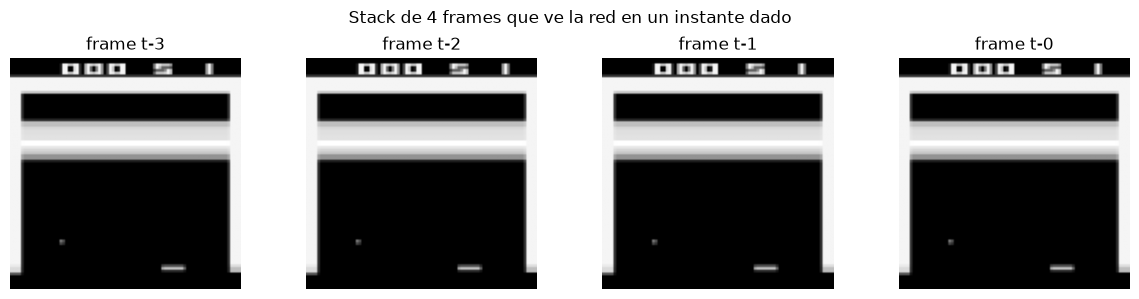

In [3]:
# | echo: false
# | eval: true

obs, _ = eval_env.reset(seed=t_config.seed)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(obs[i], cmap="gray")
    ax.set_title(f"frame t-{3 - i}")
    ax.axis("off")
fig.suptitle("Stack de 4 frames que ve la red en un instante dado")
plt.tight_layout()
plt.show()

# Entrenamiento

`train.py` corre `num_envs=8` entornos vectorizados en paralelo, recolecta rollouts de `num_steps=128` pasos (batch de 1024 transiciones) y actualiza la red con PPO:

- **Ventajas**: GAE (Schulman et al., 2016) con `gamma=0.99`, `gae_lambda=0.95`.
- **Pérdida de política**: surrogate clippeado (`clip_coef=0.1`) sobre el ratio `π_new / π_old`.
- **Pérdida de valor**: también clippeada, para evitar updates grandes en el critic.
- **Bonus de entropía** (`ent_coef=0.025`) para mantener exploración.
- 4 épocas por rollout (`update_epochs=4`), 4 minibatches por época.
- Cada `checkpoint_window=20` episodios evalúa el retorno promedio y guarda un checkpoint nuevo si supera el mejor histórico (`evaluate_and_save_checkpoint`).

A continuación se cargan las métricas logueadas en TensorBoard para el run más reciente en `runs/`.

In [4]:
# | include: false

import glob
import os

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

run_dir = r"runs/Breakout-v5__envs_8__steps_128__lr_0.00025__seed_1000"
print(f"Leyendo run: {run_dir}")

acc = EventAccumulator(run_dir)
acc.Reload()


def scalars_to_df(tag: str) -> pd.DataFrame:
    events = acc.Scalars(tag)
    return pd.DataFrame(
        {"step": [e.step for e in events], tag: [e.value for e in events]}
    ).set_index("step")


available_tags = acc.Tags()["scalars"]
print(available_tags)

Leyendo run: runs/Breakout-v5__envs_8__steps_128__lr_0.00025__seed_1000


['Eval/episodic_return', 'Eval/episodic_length', 'Eval/max_return_recent_200', 'losses/policy_loss', 'losses/value_loss', 'losses/entropy', 'losses/clip_fraction', 'losses/approx_kl', 'losses/explained_variance', 'Performance/SPS', 'Eval/avg_return_window']


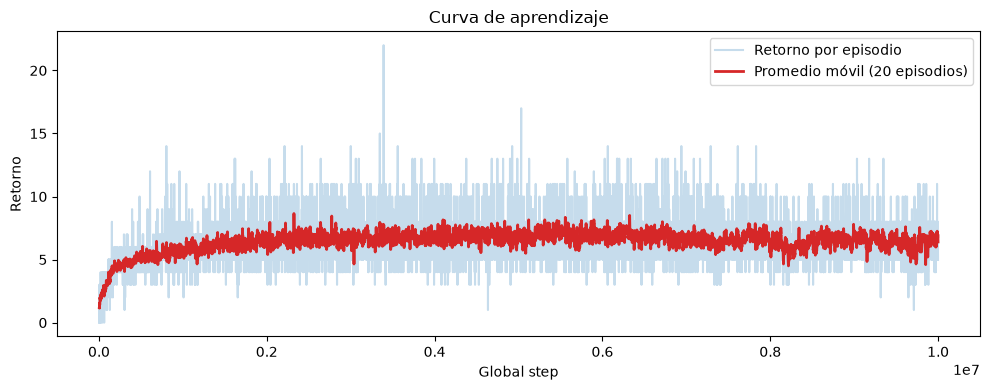

In [5]:
# | echo: false
# | eval: true

returns_df = scalars_to_df("Eval/episodic_return")
avg_return_df = scalars_to_df("Eval/avg_return_window")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    returns_df.index, returns_df["Eval/episodic_return"], alpha=0.25, label="Retorno por episodio"
)
ax.plot(
    avg_return_df.index,
    avg_return_df["Eval/avg_return_window"],
    color="tab:red",
    linewidth=2,
    label=f"Promedio móvil ({t_config.checkpoint_window} episodios)",
)
ax.set_xlabel("Global step")
ax.set_ylabel("Retorno")
ax.set_title("Curva de aprendizaje")
ax.legend()
plt.tight_layout()
plt.show()

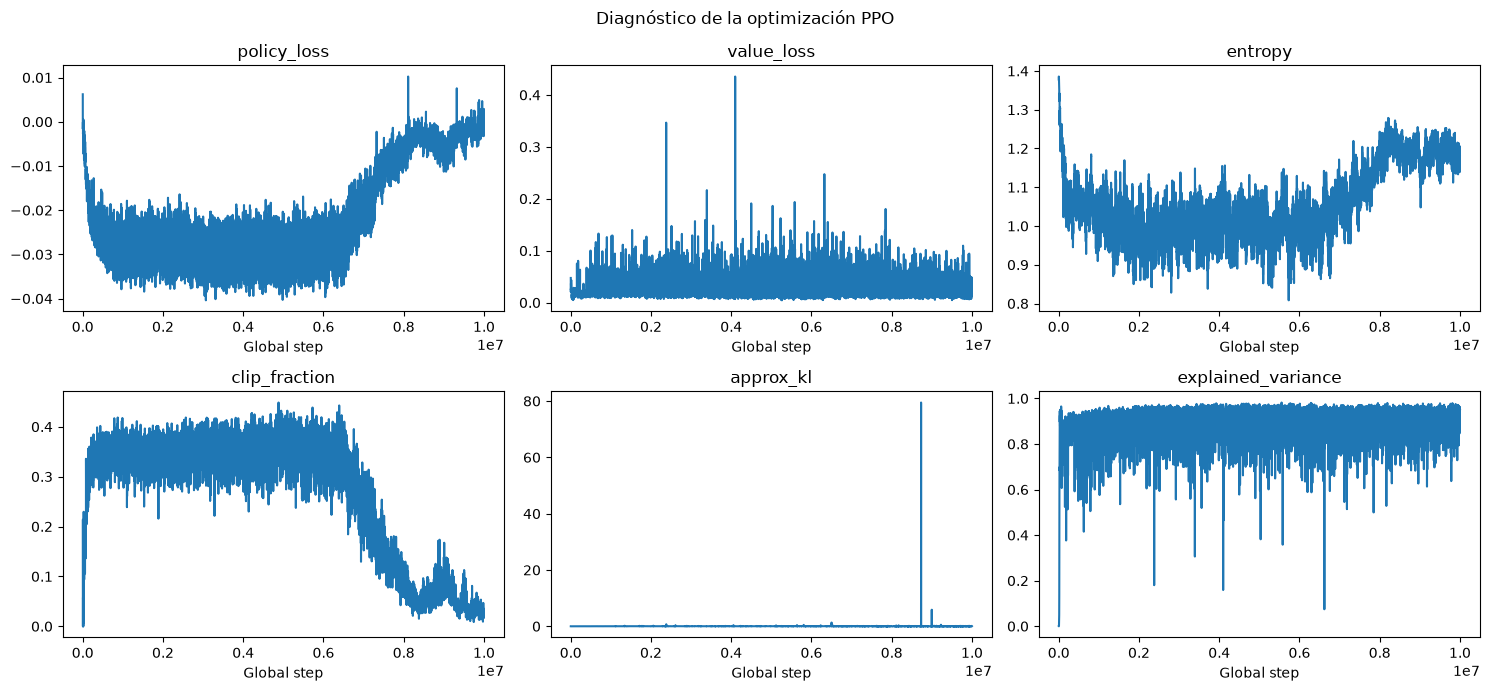

In [6]:
# | echo: false
# | eval: true

loss_tags = [t for t in available_tags if t.startswith("losses/")]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, tag in zip(axes.flat, loss_tags):
    df = scalars_to_df(tag)
    ax.plot(df.index, df[tag])
    ax.set_title(tag.replace("losses/", ""))
    ax.set_xlabel("Global step")
for ax in axes.flat[len(loss_tags) :]:
    ax.axis("off")
fig.suptitle("Diagnóstico de la optimización PPO")
plt.tight_layout()
plt.show()

**Lectura rápida de las métricas:**

- `explained_variance` cercano a 1 indica que el critic predice bien el retorno; si se queda cerca de 0 (o negativo), el value head es el cuello de botella y las ventajas de GAE llegan ruidosas a la política.
- `approx_kl` y `clip_fraction` altos indican que la política se está moviendo mucho respecto de la que generó el rollout — si crecen sin control, conviene bajar `lr` o activar `target_kl`.
- `entropy` decreciente es esperable (la política se vuelve más determinista), pero si cae demasiado rápido puede significar colapso prematuro de exploración.

# Checkpoint entrenado

Se busca el mejor checkpoint guardado (`best_agent_score_*.pt`) dentro de `checkpoints/{run_name}/` para el run cargado arriba.

In [7]:
# | include: false

best_ckpt_path = (
    r"checkpoints\Breakout-v5__envs_8__steps_128__lr_0.00025__seed_1000\best_agent_score_2.95.pt"
)
checkpoint_data = agent.load(best_ckpt_path)
agent.network.eval()

print(f"Checkpoint: {best_ckpt_path}")
print(f"Global step: {checkpoint_data['global_step']:,}")
print(
    f"Best avg return (ventana {t_config.checkpoint_window}): {checkpoint_data['best_avg_return']:.2f}"
)

Checkpoint: checkpoints\Breakout-v5__envs_8__steps_128__lr_0.00025__seed_1000\best_agent_score_2.95.pt
Global step: 55,296
Best avg return (ventana 20): 2.95


# Evaluación

Se corren episodios con política **determinista** (`argmax` sobre los logits, sin muestreo) para medir el desempeño real del checkpoint, igual que hace `evaluate()` en `visualize.py`.

In [8]:
# | echo: false
# | eval: true

N_EVAL_EPISODES = 5
eval_rewards, eval_lengths = [], []

for _ in range(N_EVAL_EPISODES):
    obs, _ = eval_env.reset()
    done = False
    total_reward, steps = 0.0, 0

    while not done:
        obs_tensor = torch.tensor(obs, device=device).unsqueeze(0)
        with torch.no_grad():
            logits, _ = agent.network(obs_tensor)
            action = torch.argmax(logits, dim=1).item()
        obs, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += float(reward)
        steps += 1
        done = terminated or truncated or steps >= 1000

    eval_rewards.append(total_reward)
    eval_lengths.append(steps)

eval_df = pd.DataFrame({"reward": eval_rewards, "length": eval_lengths})
print(eval_df.describe()[["reward", "length"]])

         reward  length
count  5.000000     5.0
mean   1.600000  1000.0
std    0.894427     0.0
min    0.000000  1000.0
25%    2.000000  1000.0
50%    2.000000  1000.0
75%    2.000000  1000.0
max    2.000000  1000.0


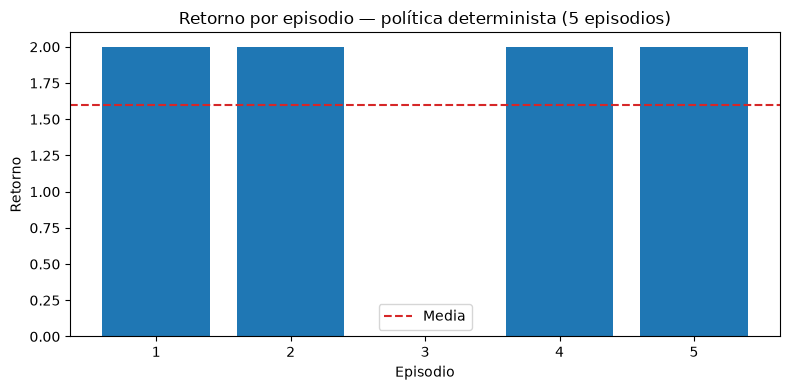

In [9]:
# | echo: false
# | eval: true

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, N_EVAL_EPISODES + 1), eval_rewards, color="tab:blue")
ax.axhline(eval_df["reward"].mean(), color="tab:red", linestyle="--", label="Media")
ax.set_xlabel("Episodio")
ax.set_ylabel("Retorno")
ax.set_title(f"Retorno por episodio — política determinista ({N_EVAL_EPISODES} episodios)")
ax.legend()
plt.tight_layout()
plt.show()

eval_env.close()

# Grabación del Agente Entrenado

A continuación se visualiza una partida del mejor agente evaluado jugando con política determinista:

In [10]:
from IPython.display import Video

# Grabación del mejor agente evaluado en Breakout-v5
Video(
    "recordings/agent_08/Breakout-v5__envs_8__steps_128__lr_0.00025__seed_1000-episode-0.mp4",
    embed=True,
    width=640,
    height=360,
)

# Referencias

Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). *Proximal Policy Optimization Algorithms*. arXiv:1707.06347.

Schulman, J., Moritz, P., Levine, S., Jordan, M., & Abbeel, P. (2016). *High-Dimensional Continuous Control Using Generalized Advantage Estimation*. ICLR.

Espeholt, L., Soyer, H., Munos, R., Simonyan, K., Mnih, V., Ward, T., ... & Kavukcuoglu, K. (2018). *IMPALA: Scalable Distributed Deep-RL with Importance Weighted Actor-Learner Architectures*. ICML.

Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). *Human-level control through deep reinforcement learning*. Nature, 518(7540), 529-533.

Bellemare, M. G., Naddaf, Y., Veness, J., & Bowling, M. (2013). *The Arcade Learning Environment: An Evaluation Platform for General Agents*. JAIR.

Towers, M., et al. (2024). *Gymnasium: A Standard Interface for Reinforcement Learning Environments*.